# General stats — database tables, field coverage, polity coverage by century, and most notable individual per polity.

In [1]:
import random
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../../data/humans_clean.duckdb'

COLORS = {
    'count_bar':   '#2171b5',
    'percent_bar': '#2d6a4f',
    'gridline':    '#bbbbbb',
}

pl.Config.set_tbl_rows(30)

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   11,
})


## Connect

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)


## Field coverage  (per-individual availability of each Wikidata property)

In [3]:
field_coverage_wide = con.execute("""
    SELECT
        COUNT(*)                                                AS total_individuals,
        COUNT(birthdate)                                        AS date_of_birth,
        COUNT(deathdate)                                        AS date_of_death,
        COUNT(birthcity_en)                                     AS place_of_birth,
        COUNT(deathcity_en)                                     AS place_of_death,
        COUNT(country_of_citizenship_en)                        AS nationality,
        COUNT(occupations_en)                                   AS occupation,
        COUNT(gender)                                           AS gender,
        COUNT(writing_language_name_en)                         AS writing_language,
        COUNT(*) FILTER (WHERE wikimedia_links_count >= 1)      AS wikipedia_sitelinks,
        COUNT(*) FILTER (WHERE identifiers_count     >= 1)      AS external_identifiers,
        (SELECT COUNT(*)                    FROM individuals_floruit_period) AS impact_date_computed,
        (SELECT COUNT(DISTINCT wikidata_id) FROM individuals_cliopatria)     AS cliopatria_polity_mapping
    FROM individuals
""").pl()

print('shape:', field_coverage_wide.shape)
field_coverage_wide


shape: (1, 13)


total_individuals,date_of_birth,date_of_death,place_of_birth,place_of_death,nationality,occupation,gender,writing_language,wikipedia_sitelinks,external_identifiers,impact_date_computed,cliopatria_polity_mapping
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
13003420,7511504,3573591,3724907,1585590,5570202,9032397,8954240,225836,4960082,11504043,13003420,5065026


In [4]:
PROPERTY_LABELS = {
    'total_individuals':         'Total individuals',
    'date_of_birth':             'Date of birth',
    'date_of_death':             'Date of death',
    'place_of_birth':            'Place of birth',
    'place_of_death':            'Place of death',
    'nationality':               'Nationality',
    'occupation':                'Occupation',
    'gender':                    'Gender',
    'writing_language':          'Writing language',
    'wikipedia_sitelinks':       'Wikipedia wikimedia_links (>=1)',
    'external_identifiers':      'External identifiers (>=1)',
    'impact_date_computed':      'Impact date (computed)',
    'cliopatria_polity_mapping': 'Cliopatria polity mapping',
}

total_individuals = field_coverage_wide['total_individuals'].item()

field_coverage = (
    field_coverage_wide
    .transpose(include_header=True, header_name='Property', column_names=['Individuals'])
    .with_columns(
        pl.col('Property').replace(PROPERTY_LABELS),
        (pl.col('Individuals').cast(pl.Float64) / total_individuals * 100).round(1).alias('% of total'),
    )
)

print('shape:', field_coverage.shape)
field_coverage


shape: (13, 3)


Property,Individuals,% of total
str,i64,f64
"""Total individuals""",13003420,100.0
"""Date of birth""",7511504,57.8
"""Date of death""",3573591,27.5
"""Place of birth""",3724907,28.6
"""Place of death""",1585590,12.2
"""Nationality""",5570202,42.8
"""Occupation""",9032397,69.5
"""Gender""",8954240,68.9
"""Writing language""",225836,1.7


## Core counts  (rows in each major table)

In [5]:
core_counts = con.execute("""
    SELECT 'individuals'              AS table_name, COUNT(*) AS rows FROM individuals
    UNION ALL SELECT 'places',                       COUNT(*)         FROM places
    UNION ALL SELECT 'places (urban settlement)',    COUNT(*)         FROM places WHERE is_urban_settlement = 1
    UNION ALL SELECT 'occupations',                  COUNT(*)         FROM occupations
    UNION ALL SELECT 'writing_languages',            COUNT(*)         FROM writing_languages
    UNION ALL SELECT 'country_of_citizenship',       COUNT(*)         FROM country_of_citizenship
    UNION ALL SELECT 'identifiers',                  COUNT(*)         FROM identifiers
    UNION ALL SELECT 'identifier_types',             COUNT(*)         FROM identifier_types
    UNION ALL SELECT 'wikimedia_links',              COUNT(*)         FROM wikimedia_links
    UNION ALL SELECT 'works',                        COUNT(*)         FROM works
    UNION ALL SELECT 'individuals_cliopatria',       COUNT(*)         FROM individuals_cliopatria
    UNION ALL SELECT 'polities_cliopatria',          COUNT(*)         FROM polities_cliopatria
""").pl()

print('shape:', core_counts.shape)
core_counts


shape: (12, 2)


table_name,rows
str,i64
"""individuals""",13003420
"""places""",314724
"""places (urban settlement)""",257269
"""occupations""",18230
"""writing_languages""",524
"""country_of_citizenship""",4572
"""identifiers""",59508342
"""identifier_types""",5169
"""wikimedia_links""",15551839


## Coverage criteria  (combined predicates over individuals)

In [6]:
individual_flags = con.execute("""
    SELECT
        (birthcity_en              IS NOT NULL AND birthcity_en              != '') AS has_birthplace,
        (deathcity_en              IS NOT NULL AND deathcity_en              != '') AS has_deathplace,
        (country_of_citizenship_en IS NOT NULL AND country_of_citizenship_en != '') AS has_citizenship,
        (birthdate                 IS NOT NULL AND birthdate                 != '') AS has_birthdate,
        (deathdate                 IS NOT NULL AND deathdate                 != '') AS has_deathdate,
        (floruit_date              IS NOT NULL AND floruit_date              != '') AS has_floruit,
        (identifiers_count     >= 1)                                                AS has_identifier,
        (wikimedia_links_count >= 1)                                                AS has_sitelink
    FROM individuals
""").pl()

print('shape:', individual_flags.shape)
individual_flags.head()


shape: (13003420, 8)


has_birthplace,has_deathplace,has_citizenship,has_birthdate,has_deathdate,has_floruit,has_identifier,has_sitelink
bool,bool,bool,bool,bool,bool,bool,bool
true,true,true,true,true,false,true,true
true,true,true,true,true,false,true,true
false,false,true,false,false,false,false,false
true,true,true,true,true,false,true,true
true,false,true,true,false,false,true,true


In [7]:
has_place = individual_flags['has_birthplace'] | individual_flags['has_deathplace'] | individual_flags['has_citizenship']
has_date  = individual_flags['has_birthdate']  | individual_flags['has_deathdate']  | individual_flags['has_floruit']
has_link  = individual_flags['has_identifier'] | individual_flags['has_sitelink']

coverage_criteria = pl.DataFrame({
    'criterion': [
        'any_place',
        'any_date',
        'any_identifier_or_sitelink',
        'place_and_date_and_link',
    ],
    'individuals': [
        has_place.sum(),
        has_date.sum(),
        has_link.sum(),
        (has_place & has_date & has_link).sum(),
    ],
}).with_columns(
    (pl.col('individuals').cast(pl.Float64) / total_individuals * 100).round(1).alias('pct_of_total'),
)

print('shape:', coverage_criteria.shape)
coverage_criteria


shape: (4, 3)


criterion,individuals,pct_of_total
str,i64,f64
"""any_place""",6376888,49.0
"""any_date""",7813121,60.1
"""any_identifier_or_sitelink""",12060106,92.7
"""place_and_date_and_link""",5108096,39.3


## Removed entries  (non-historical / fictional individuals)

In [8]:
removed_entries = con.execute("""
    SELECT 'P31 = fictional / mythical / legendary / deity (non_human flag)' AS filter,
           COUNT(*)                                                          AS count
    FROM individuals WHERE non_human = 1
    UNION ALL
    SELECT 'country_of_citizenship instance = fictional polity',
           COUNT(*)
    FROM country_of_citizenship
    WHERE LOWER(instance_labels) LIKE '%fictional%' OR LOWER(instance_labels) LIKE '%mytholog%'
""").pl()

print('shape:', removed_entries.shape)
removed_entries


shape: (2, 2)


filter,count
str,i64
"""P31 = fictional / mythical / l…",872
"""country_of_citizenship instanc…",350


## Top 20 work types  (instance_of of `works` rows)

In [9]:
top_work_types = con.execute("""
    SELECT instance_of_en AS work_type,
           COUNT(*)       AS works
    FROM works
    WHERE instance_of_en IS NOT NULL
    GROUP BY work_type
    ORDER BY works DESC
    LIMIT 20
""").pl()

print('shape:', top_work_types.shape)
top_work_types


shape: (20, 2)


work_type,works
str,i64
"""scholarly article""",32173225
"""painting""",740284
"""film""",630308
"""version, edition or translatio…",582189
"""literary work""",433964
"""motion""",337557
"""album""",218054
"""scholarly article|meta-analysi…",211302
"""scholarly article|erratum""",208837


## Polity coverage by century — counts (log scale)

In [10]:
CENTURY_MIN = -3500
CENTURY_MAX = 2000
MIN_INDIVIDUALS_PER_CENTURY = 5

polity_count_per_century = con.execute(f"""
    SELECT CAST(FLOOR(floruit_period_start / 100.0) * 100 AS INTEGER) AS century,
           COUNT(DISTINCT wikidata_id)                                AS individuals_with_polity
    FROM individuals_cliopatria
    WHERE floruit_period_start BETWEEN {CENTURY_MIN} AND {CENTURY_MAX}
    GROUP BY century
    HAVING individuals_with_polity >= {MIN_INDIVIDUALS_PER_CENTURY}
    ORDER BY century
""").pl()

print('shape:', polity_count_per_century.shape)
polity_count_per_century.head()


shape: (50, 2)


century,individuals_with_polity
i32,i64
-3000,5
-2800,6
-2700,5
-2600,17
-2500,25


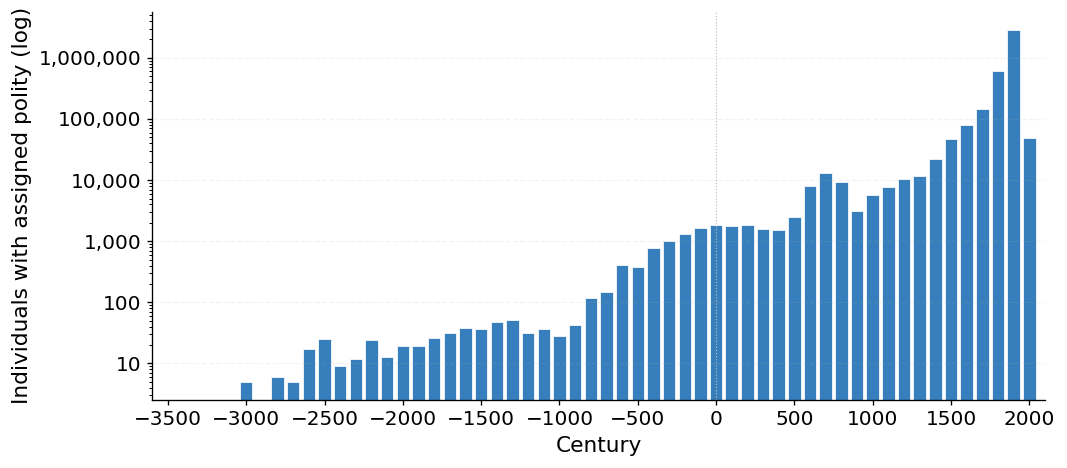

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(
    polity_count_per_century['century'].to_list(),
    polity_count_per_century['individuals_with_polity'].to_list(),
    width=80, color=COLORS['count_bar'], edgecolor='white', linewidth=0.5, alpha=0.9,
)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))
ax.set_xlabel('Century')
ax.set_ylabel('Individuals with assigned polity (log)')
ax.set_xlim(-3600, 2100)
ax.set_xticks(list(range(-3500, 2500, 500)))
ax.tick_params(axis='both', length=3)
ax.grid(axis='y', alpha=0.15, linestyle='--')
ax.axvline(x=0, color=COLORS['gridline'], linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()


## Polity coverage by century — % of individuals (with floruit) assigned to a polity

In [12]:
floruit_count_per_century = con.execute(f"""
    SELECT CAST(FLOOR(floruit_period_start / 100.0) * 100 AS INTEGER) AS century,
           COUNT(DISTINCT wikidata_id)                                AS total_with_floruit
    FROM individuals_floruit_period
    WHERE floruit_period_start BETWEEN {CENTURY_MIN} AND {CENTURY_MAX}
    GROUP BY century
    ORDER BY century
""").pl()

print('shape:', floruit_count_per_century.shape)
floruit_count_per_century.head()


shape: (55, 2)


century,total_with_floruit
i32,i64
-3500,10
-3300,1
-3200,7
-3100,9
-3000,24


In [13]:
polity_share_per_century = (
    floruit_count_per_century
    .join(polity_count_per_century, on='century', how='left')
    .with_columns(pl.col('individuals_with_polity').fill_null(0))
    .filter(pl.col('total_with_floruit') >= MIN_INDIVIDUALS_PER_CENTURY)
    .with_columns(
        (pl.col('individuals_with_polity').cast(pl.Float64) / pl.col('total_with_floruit') * 100)
        .round(1).alias('pct_with_polity'),
    )
)

overall_pct = (
    polity_share_per_century['individuals_with_polity'].sum()
    / polity_share_per_century['total_with_floruit'].sum() * 100
)
print(f'overall coverage: {overall_pct:.1f}%')
print('shape:', polity_share_per_century.shape)
polity_share_per_century.head()


overall coverage: 64.5%
shape: (54, 4)


century,total_with_floruit,individuals_with_polity,pct_with_polity
i32,i64,i64,f64
-3500,10,0,0.0
-3200,7,0,0.0
-3100,9,0,0.0
-3000,24,5,20.8
-2900,14,0,0.0


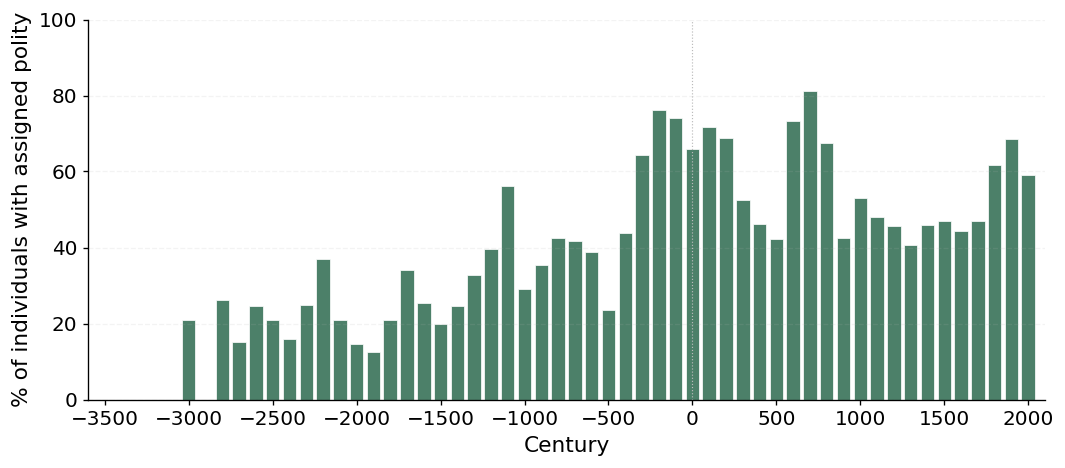

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(
    polity_share_per_century['century'].to_list(),
    polity_share_per_century['pct_with_polity'].to_list(),
    width=80, color=COLORS['percent_bar'], edgecolor='white', linewidth=0.5, alpha=0.85,
)
ax.set_xlabel('Century')
ax.set_ylabel('% of individuals with assigned polity')
ax.set_xlim(-3600, 2100)
ax.set_ylim(0, 100)
ax.set_xticks(list(range(-3500, 2500, 500)))
ax.tick_params(axis='both', length=3)
ax.grid(axis='y', alpha=0.15, linestyle='--')
ax.axvline(x=0, color=COLORS['gridline'], linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()


## 20 famous polities — most notable individual per polity

In [15]:
FAMOUS_POLITIES = [
    (6,    'Akkadian Empire'),
    (23,   'New Kingdom of Egypt'),
    (91,   'Achaemenid Empire'),
    (65,   'Macedonian Empire'),
    (93,   'Roman Republic'),
    (114,  'Ptolemaic Kingdom'),
    (204,  'Roman Empire'),
    (223,  'Sasanian Empire'),
    (366,  'Tang Dynasty'),
    (402,  'Carolingian Empire'),
    (414,  'Abbasid Caliphate'),
    (373,  'Byzantine Empire'),
    (729,  'Mongol Empire'),
    (397,  'Republic of Venice'),
    (523,  'Holy Roman Empire'),
    (896,  'Ming Dynasty'),
    (839,  'Ottoman Empire'),
    (1050, 'Tokugawa Shogunate'),
    (1117, 'Russian Empire'),
    (1102, 'Kingdom of Great Britain'),
]

famous_polity_ids = [polity_id for polity_id, _ in FAMOUS_POLITIES]

famous_polity_names = pl.DataFrame(
    FAMOUS_POLITIES,
    schema=['polity_id', 'polity_name'],
    orient='row',
)
print('shape:', famous_polity_names.shape)
famous_polity_names.head()


shape: (20, 2)


polity_id,polity_name
i64,str
6,"""Akkadian Empire"""
23,"""New Kingdom of Egypt"""
91,"""Achaemenid Empire"""
65,"""Macedonian Empire"""
93,"""Roman Republic"""


## Polity periods  (from polities_periods_cliopatria — never invented)

In [16]:
polity_periods = con.execute("""
    SELECT polity_id,
           MIN(from_year) AS year_start,
           MAX(to_year)   AS year_end
    FROM polities_periods_cliopatria
    WHERE polity_id = ANY(?)
    GROUP BY polity_id
""", [famous_polity_ids]).pl()

print('shape:', polity_periods.shape)
polity_periods.head()


shape: (20, 3)


polity_id,year_start,year_end
i64,i64,i64
6,-2300,-2101
23,-1500,-801
65,-675,-292
91,-550,-327
93,-500,-32


## Most notable per polity  (argmax of `individuals.notability_general`)

In [17]:
top_qid_per_polity = con.execute("""
    SELECT ic.polity_id,
           ARG_MAX(ic.wikidata_id, i.notability_general) AS wikidata_id
    FROM      individuals_cliopatria ic
    JOIN      individuals             i USING(wikidata_id)
    WHERE     ic.polity_id = ANY(?)
    GROUP BY  ic.polity_id
""", [famous_polity_ids]).pl()

print('shape:', top_qid_per_polity.shape)
top_qid_per_polity.head()


shape: (20, 2)


polity_id,wikidata_id
i64,str
6,"""Q199461"""
23,"""Q12154"""
65,"""Q48305"""
91,"""Q8423"""
93,"""Q1048"""


In [18]:
notable_individuals = con.execute("""
    SELECT wikidata_id,
           name_en,
           description_en,
           birthdate,
           deathdate,
           notability_general,
           notability_western,
           notability_non_western,
           wikimedia_links_count
    FROM   individuals
    WHERE  wikidata_id = ANY(?)
""", [top_qid_per_polity['wikidata_id'].to_list()]).pl()

print('shape:', notable_individuals.shape)
notable_individuals.head()


shape: (20, 9)


wikidata_id,name_en,description_en,birthdate,deathdate,notability_general,notability_western,notability_non_western,wikimedia_links_count
str,str,str,str,str,f64,i64,i64,i64
"""Q302""","""Jesus Christ""","""central figure of Christianity…","""-0005-01-01""","""0033-04-01""",169.699735,154,187,341
"""Q3044""","""Charlemagne""","""king of Franks, regarded as th…","""0748-04-06""","""0814-02-01""",116.884558,138,99,184
"""Q199461""","""Sargon of Akkad""","""founder of Akkadian Empire""","""-2350-01-01""","""-2300-01-01""",45.497253,46,45,78
"""Q5879""","""Johann Wolfgang von Goethe""","""German writer, artist, natural…","""1749-08-28""","""1832-03-22""",173.51657,193,156,274
"""Q6101""","""Marco Polo""","""Venetian explorer and merchant…","""1254-09-22""","""1324-01-16""",130.938917,135,127,210


## Final table  (polity name + period + most notable individual)

In [19]:
def format_year(year):
    if year is None:
        return ''
    year = int(year)
    return f'{abs(year)} BCE' if year < 0 else f'{year} CE'

def format_period(year_start, year_end):
    return f'{format_year(year_start)} – {format_year(year_end)}'

def parse_year_from_iso(iso_date):
    if iso_date is None or iso_date == '' or str(iso_date).startswith('_:'):
        return None
    iso_date = str(iso_date)
    sign = -1 if iso_date.startswith('-') else 1
    body = iso_date[1:] if iso_date.startswith('-') else iso_date
    try:
        return sign * int(body.split('-')[0])
    except ValueError:
        return None

def format_lifespan(birthdate, deathdate):
    birth_year = parse_year_from_iso(birthdate)
    death_year = parse_year_from_iso(deathdate)
    if birth_year is None and death_year is None:
        return ''
    return f'{format_year(birth_year) if birth_year is not None else "?"} – {format_year(death_year) if death_year is not None else "?"}'

notable_per_polity = (
    famous_polity_names
    .join(polity_periods,      on='polity_id',   how='left')
    .join(top_qid_per_polity,  on='polity_id',   how='left')
    .join(notable_individuals, on='wikidata_id', how='left')
    .sort('year_start')
    .with_columns(
        pl.struct(['year_start', 'year_end']).map_elements(
            lambda r: format_period(r['year_start'], r['year_end']),
            return_dtype=pl.String,
        ).alias('period'),
        pl.struct(['birthdate', 'deathdate']).map_elements(
            lambda r: format_lifespan(r['birthdate'], r['deathdate']),
            return_dtype=pl.String,
        ).alias('lifespan'),
        pl.col('notability_general').round(1),
    )
    .select(
        'polity_name',
        'period',
        'name_en',
        'lifespan',
        'description_en',
        'notability_general',
        'notability_western',
        'notability_non_western',
        'wikimedia_links_count',
    )
)

with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=240):
    print(notable_per_polity)


shape: (20, 9)
┌──────────────────────────┬─────────────────────┬────────────────────────────┬─────────────────────┬─────────────────────────────────┬────────────────────┬────────────────────┬────────────────────────┬───────────────────────┐
│ polity_name              ┆ period              ┆ name_en                    ┆ lifespan            ┆ description_en                  ┆ notability_general ┆ notability_western ┆ notability_non_western ┆ wikimedia_links_count │
│ ---                      ┆ ---                 ┆ ---                        ┆ ---                 ┆ ---                             ┆ ---                ┆ ---                ┆ ---                    ┆ ---                   │
│ str                      ┆ str                 ┆ str                        ┆ str                 ┆ str                             ┆ f64                ┆ i64                ┆ i64                    ┆ i64                   │
╞══════════════════════════╪═════════════════════╪═══════════════════════════